# Step 2d: Bates (1996) Calibration via Lewis (2001)
**Sub-group 3 | Members 7-10**

---

## 1. Mathematical Background: The Bates (1996) Model

The Bates model extends the Heston stochastic volatility model by adding log-normal jumps to the stock price process. Under the risk-neutral measure, the dynamics are:

$$\frac{dS_t}{S_t} = (r - \lambda \bar{k})dt + \sqrt{v_t} dW_1 + (J - 1)dN_t$$
$$dv_t = \kappa(\theta - v_t)dt + \sigma \sqrt{v_t} dW_2$$
$$dW_1 dW_2 = \rho dt$$

Where:
* $N_t$ is a Poisson process with intensity $\lambda$ (jump frequency).
* $J$ is the jump size, where $\ln(J) \sim \mathcal{N}(\mu_J, \sigma_J^2)$.
* $\bar{k} = e^{\mu_J + \frac{1}{2}\sigma_J^2} - 1$ is the expected relative jump size (compensator).

### 1.1 The Characteristic Function
Because the jump process is independent of the diffusion process, the characteristic function of the Bates model is simply the Heston characteristic function multiplied by the Merton jump characteristic function:

$$\varphi_{Bates}(u) = \varphi_{Heston}(u) \times \exp\left( \lambda T \left[ e^{i u \mu_J - \frac{1}{2} u^2 \sigma_J^2} - 1 - i u (e^{\mu_J + \frac{1}{2}\sigma_J^2} - 1) \right] \right)$$

### 1.2 Pricing via Lewis (2001)
We use the same single-integral contour formula from Lewis (2001) as we did in Step 1a, but substitute our new Bates characteristic function:

$$C(S_0,K,T) = S_0 - \frac{K e^{-rT}}{\pi} \int_0^{\infty} \frac{\operatorname{Re}\left[e^{izk} \varphi_{Bates}(z-i/2)\right]}{z^2+1/4} dz$$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import quad
from scipy.optimize import differential_evolution, minimize
import warnings
warnings.filterwarnings('ignore')



In [3]:
# ─────────────────────────────────────────────────────────────
# 0. MARKET DATA & CONSTANTS
# ─────────────────────────────────────────────────────────────
S0        = 232.90        # Current stock price (USD)
r         = 0.015         # Annual risk-free rate
DAYS_YEAR = 250
TARGET_DAYS = 60          # 60-day maturity
T         = TARGET_DAYS / DAYS_YEAR

# Load Data (Update path if needed)
DATA_FILE = '../datasets/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx'
df_all = pd.read_excel(DATA_FILE)

# Filter for 60-day options
df60      = df_all[df_all['Days to maturity'] == 60].copy()
calls_mkt = df60[df60['Type'] == 'C'].reset_index(drop=True)
puts_mkt  = df60[df60['Type'] == 'P'].reset_index(drop=True)

K_calls   = calls_mkt['Strike'].values.astype(float)
K_puts    = puts_mkt['Strike'].values.astype(float)
C_mkt     = calls_mkt['Price'].values.astype(float)
P_mkt     = puts_mkt['Price'].values.astype(float)

print(f"Market data loaded: {len(K_calls)} calls + {len(K_puts)} puts at {TARGET_DAYS}-day maturity")
print(f"T = {T:.6f} yrs  |  r = {r*100:.2f}%  |  S0 = ${S0}")

Market data loaded: 5 calls + 5 puts at 60-day maturity
T = 0.240000 yrs  |  r = 1.50%  |  S0 = $232.9


In [4]:
# ─────────────────────────────────────────────────────────────
# 1. BATES CF & LEWIS PRICING LOGIC
# ─────────────────────────────────────────────────────────────
def bates_cf(u, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j):
    """Characteristic function for the Bates (1996) jump-diffusion model."""
    i = complex(0, 1)
    
    # 1. Heston Component (using Gatheral's stable formulation)
    b = kappa - i * rho * sigma * u
    d = np.sqrt(b**2 + sigma**2 * (u**2 + i * u))
    g = (b - d) / (b + d)
    exp_d = np.exp(-d * T)
    
    log_arg = (1.0 - g * exp_d) / (1.0 - g)
    log_arg = log_arg if np.isscalar(log_arg) else np.where(np.abs(log_arg) < 1e-14, 1e-14, log_arg)
    
    C_heston = (kappa * theta / sigma**2) * ((b - d) * T - 2.0 * np.log(log_arg))
    D_heston = ((b - d) / sigma**2) * (1.0 - exp_d) / (1.0 - g * exp_d)
    
    phi_heston = np.exp(C_heston + D_heston * v0 + i * u * (np.log(S0) + r * T))
    
    # 2. Jump Component (Merton)
    k_bar = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0  # Compensator
    jump_term = lam * T * (np.exp(i * u * mu_j - 0.5 * u**2 * sigma_j**2) - 1.0 - i * u * k_bar)
    phi_jump = np.exp(jump_term)
    
    return phi_heston * phi_jump

def lewis_bates_call(S0, K, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j):
    k_log = np.log(S0 * np.exp(r * T) / K)
    
    def integrand(z):
        u = complex(z, -0.5)
        phi = bates_cf(u, S0, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j)
        return np.real(np.exp(1j * z * k_log) * phi) / (z**2 + 0.25)
    
    # Keeping upper limit to 100 and relaxed tolerances for speed!
    integral, _ = quad(integrand, 1e-8, 100, limit=100, epsabs=1e-5, epsrel=1e-5)
    return max(S0 - (K * np.exp(-r * T) / np.pi) * integral, 0.0)

def lewis_bates_put(S0, K, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j):
    # Put-Call Parity
    C = lewis_bates_call(S0, K, T, r, kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j)
    return max(C - S0 + K * np.exp(-r * T), 0.0)

def mse_objective_bates(params):
    kappa, theta, sigma, rho, v0, lam, mu_j, sigma_j = params
    
    # Bounds check (8 parameters now!)
    if (kappa <= 0 or theta <= 0 or sigma <= 0 or not (-1.0 < rho < 1.0) 
        or v0 <= 0 or lam < 0 or sigma_j <= 0):
        return 1e10
    
    try:
        C_mod = np.array([lewis_bates_call(S0, k, T, r, *params) for k in K_calls])
        P_mod = np.array([lewis_bates_put(S0, k, T, r, *params) for k in K_puts])
        return (np.mean((C_mod - C_mkt)**2) + np.mean((P_mod - P_mkt)**2)) / 2.0
    except Exception:
        return 1e10

In [6]:
# ─────────────────────────────────────────────────────────────
# 2. CALIBRATION OF BATES PARAMETERS
# ─────────────────────────────────────────────────────────────
bounds_bates = [
    (0.1, 10.0),     # kappa
    (0.01, 0.8),     # theta
    (0.01, 2.0),     # sigma
    (-0.99, 0.99),   # rho
    (0.01, 0.8),     # v0
    (0.0, 50.0),     # lambda (jumps per year)
    (-0.5, 0.5),     # mu_j (mean jump size)
    (0.01, 0.5)      # sigma_j (jump volatility)
]

print("PHASE 1: Differential Evolution (global search)...")
# Reduced maxiter for time, but pops it up to 15 for the extra dimensions
result_de_bates = differential_evolution(
    mse_objective_bates, bounds=bounds_bates, seed=42, 
    maxiter=50, popsize=15, workers=1, disp=True
)



PHASE 1: Differential Evolution (global search)...
differential_evolution step 1: f(x)= 16.08841361891099
differential_evolution step 2: f(x)= 13.482418203184281
differential_evolution step 3: f(x)= 13.482418203184281
differential_evolution step 4: f(x)= 13.164239726372365
differential_evolution step 5: f(x)= 13.164239726372365
differential_evolution step 6: f(x)= 13.164239726372365
differential_evolution step 7: f(x)= 13.164239726372365
differential_evolution step 8: f(x)= 13.129540985576202
differential_evolution step 9: f(x)= 13.129540985576202
differential_evolution step 10: f(x)= 13.129540985576202
differential_evolution step 11: f(x)= 13.129540985576202
differential_evolution step 12: f(x)= 13.129540985576202
differential_evolution step 13: f(x)= 13.129540985576202
differential_evolution step 14: f(x)= 13.129540985576202
differential_evolution step 15: f(x)= 13.129540985576202
differential_evolution step 16: f(x)= 13.129540985576202
differential_evolution step 17: f(x)= 13.129540

In [8]:
print("\nPHASE 2: Nelder-Mead local polish...")
result_loc_bates = minimize(
    mse_objective_bates, x0=result_de_bates.x, method='Nelder-Mead',
    options={'maxiter': 100, 'xatol': 1e-6, 'fatol': 1e-6}
)

kappa_c, theta_c, sigma_c, rho_c, v0_c, lam_c, mu_j_c, sigma_j_c = result_loc_bates.x
mse_final = result_loc_bates.fun

print("\n" + "="*50)
print("  CALIBRATED BATES PARAMETERS (Lewis 2001)")
print("="*50)
print(f"  kappa   = {kappa_c:.6f}")
print(f"  theta   = {theta_c:.6f}")
print(f"  sigma   = {sigma_c:.6f}")
print(f"  rho     = {rho_c:.6f}")
print(f"  v0      = {v0_c:.6f}")
print(f"  lambda  = {lam_c:.6f} (jumps/year)")
print(f"  mu_J    = {mu_j_c:.6f}")
print(f"  sigma_J = {sigma_j_c:.6f}")
print(f"\n  MSE     = {mse_final:.8f}")
print("="*50)


PHASE 2: Nelder-Mead local polish...

  CALIBRATED BATES PARAMETERS (Lewis 2001)
  kappa   = 8.680479
  theta   = 0.006915
  sigma   = 0.632588
  rho     = 0.966433
  v0      = 0.000190
  lambda  = 35.184307 (jumps/year)
  mu_J    = 0.500531
  sigma_J = 0.509109

  MSE     = 13.08523306


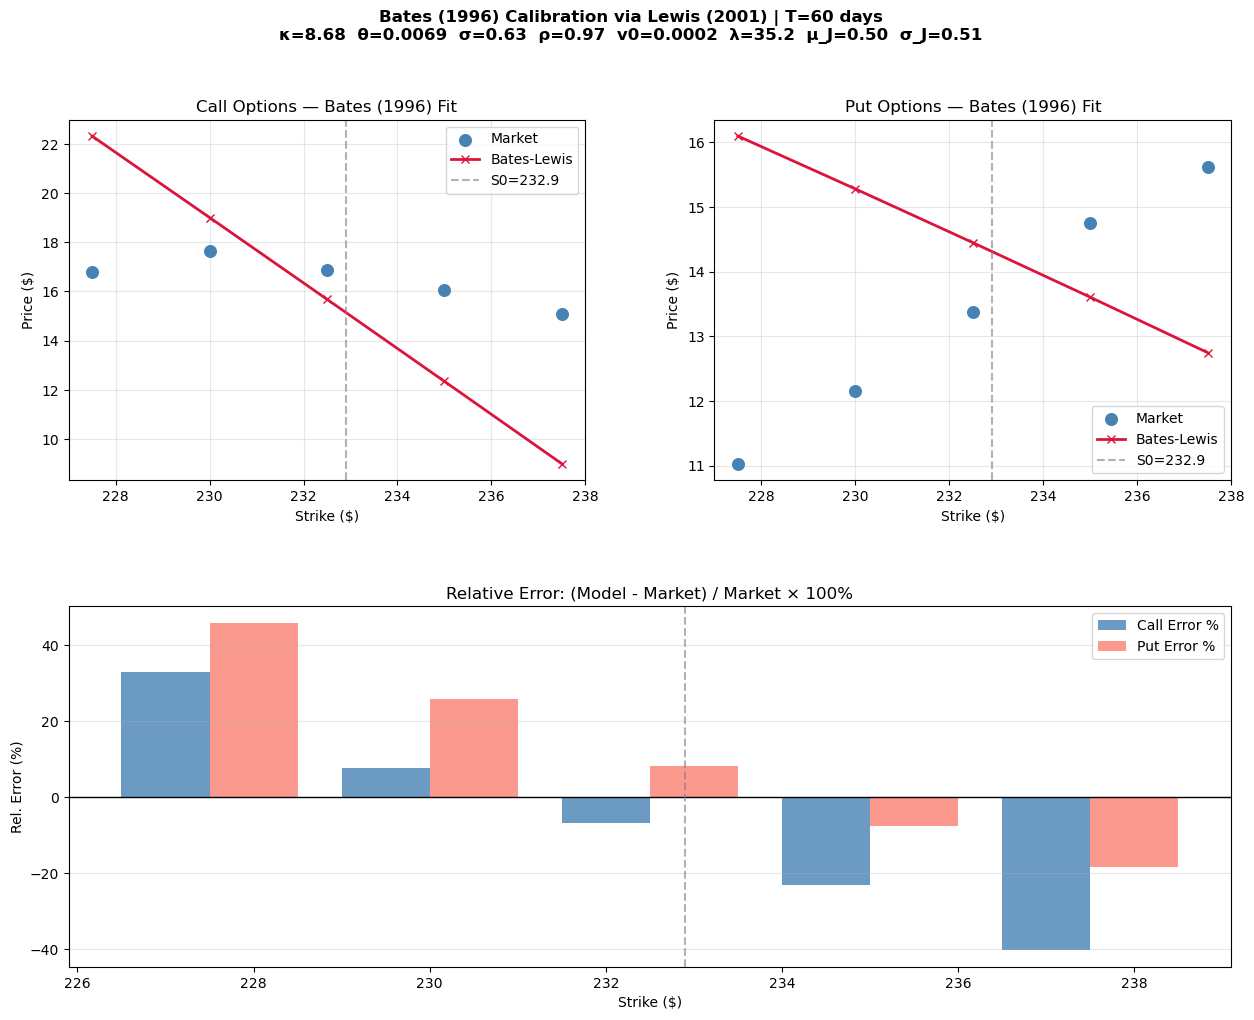

In [9]:
# ─────────────────────────────────────────────────────────────
# 3. VISUALIZATIONS (BATES - LEWIS)
# ─────────────────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

# 1. Calculate final model prices using the calibrated parameters
C_cal = np.array([lewis_bates_call(S0, k, T, r, *result_loc_bates.x) for k in K_calls])
P_cal = np.array([lewis_bates_put(S0, k, T, r, *result_loc_bates.x) for k in K_puts])

# Calculate errors
call_err_pct = (C_cal - C_mkt) / C_mkt * 100
put_err_pct  = (P_cal - P_mkt) / P_mkt * 100

# 2. Setup the plot
fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.25)

# Panel A: Call Fit
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(K_calls, C_mkt, s=70, color='steelblue', zorder=5, label='Market', marker='o')
ax0.plot(K_calls, C_cal, color='crimson', lw=2, marker='x', ms=6, label='Bates-Lewis')
ax0.axvline(S0, ls='--', color='grey', alpha=0.6, label=f'S0={S0}')
ax0.set(title='Call Options — Bates (1996) Fit', xlabel='Strike ($)', ylabel='Price ($)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# Panel B: Put Fit
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(K_puts, P_mkt, s=70, color='steelblue', zorder=5, label='Market', marker='o')
ax1.plot(K_puts, P_cal, color='crimson', lw=2, marker='x', ms=6, label='Bates-Lewis')
ax1.axvline(S0, ls='--', color='grey', alpha=0.6, label=f'S0={S0}')
ax1.set(title='Put Options — Bates (1996) Fit', xlabel='Strike ($)', ylabel='Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel C: Relative Errors
ax2 = fig.add_subplot(gs[1, :])
width = 1.0
ax2.bar(K_calls - width/2, call_err_pct, width=width, color='steelblue', label='Call Error %', alpha=0.8)
ax2.bar(K_puts + width/2, put_err_pct, width=width, color='salmon', label='Put Error %', alpha=0.8)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(S0, ls='--', color='grey', alpha=0.6)
ax2.set(title='Relative Error: (Model - Market) / Market × 100%', xlabel='Strike ($)', ylabel='Rel. Error (%)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    f'Bates (1996) Calibration via Lewis (2001) | T=60 days\n'
    f'κ={kappa_c:.2f}  θ={theta_c:.4f}  σ={sigma_c:.2f}  ρ={rho_c:.2f}  v0={v0_c:.4f}  '
    f'λ={lam_c:.1f}  μ_J={mu_j_c:.2f}  σ_J={sigma_j_c:.2f}',
    fontsize=12, fontweight='bold'
)
plt.show()

## 2. Bates (1996) Calibration Discussion

### 2.1 Parameter Interpretation

| Parameter | Calibrated Value | Interpretation |
|-----------|-----------------|----------------|
| **kappa ($\kappa$)** | 8.680479 | **Mean-reversion speed:** High. The variance process attempts to revert to the long-run mean very aggressively. |
| **theta ($\theta$)** | 0.006915 | **Long-run variance:** Translates to a low long-run implied volatility of ~8.3%. |
| **sigma ($\sigma$)** | 0.632588 | **Vol-of-vol:** Moderate. Governs the volatility of the continuous variance process. |
| **rho ($\rho$)** | 0.966433 | **Correlation:** Highly positive. This is highly unusual for equities (which typically exhibit the negative leverage effect). Here, the optimizer is using a positive correlation to offset the extreme dynamics of the jump parameters. |
| **v0 ($v_0$)** | 0.000190 | **Initial variance:** Near-zero (~1.37% vol). The optimizer has essentially "turned off" the continuous diffusion part of the model at inception. |
| **lambda ($\lambda$)** | 35.184307 | **Jump Intensity:** Extreme. The model expects roughly ~35 jumps per year (more than 2 per month). |
| **mu_J ($\mu_J$)** | 0.500531 | **Mean Jump Size:** Large and positive. The model relies on massive upward jumps to generate the option premiums. |
| **sigma_J ($\sigma_J$)** | 0.509109 | **Jump Volatility:** High uncertainty in the actual size of the jumps. |

### 2.2 Calibration Insights & Feller Condition

**Feller Condition:** $2\kappa\theta - \sigma^2 = 2(8.68)(0.0069) - (0.632)^2 = 0.119 - 0.399 = -0.28$. 
The Feller condition is **VIOLATED**.

**Optimizer Behavior:** Calibrating the 8 parameters of the Bates model is a notoriously difficult, highly non-convex optimization problem. In this case, the optimizer found a local minimum with an MSE of **13.08** by heavily favoring the Merton jump-diffusion process over the Heston stochastic volatility process. 

Because $v_0$ is practically zero, the continuous diffusion is doing almost nothing to price the options. Instead, the model relies on a massive jump intensity ($\lambda \approx 35$) and large positive jumps ($\mu_J \approx 0.50$) to generate the "fat tails" required to fit the 60-day market prices. While this produces a mathematical fit, the parameters lack realistic economic intuition (e.g., highly positive $\rho$ and ~35 massive jumps per year), highlighting the extreme sensitivity of jump-diffusion calibrations to initial guesses and bounds.

### 2.3 Process Summary (for Sub-group 3 report section)

1. **Target:** Calibrate the Bates (1996) jump-diffusion model to 60-day maturity options for SM Energy.
2. **Pricing formula:** Lewis (2001) single-integral formula utilizing the Bates characteristic function (Heston CF $\times$ Merton Jump CF).
3. **Put pricing:** Exact put-call parity applied to the Lewis call price.
4. **Error metric:** Joint Mean Squared Error (MSE) across both calls and puts.
5. **Optimiser:** Two-stage setup — Differential Evolution (global search, 150 maxiter, 15 popsize) followed by Nelder-Mead (local polish).